In [1]:
import os
try:
    path_initialized
except NameError:
    path_initialized = True
    os.chdir('..')

import numpy as np
from sympy.abc import x, y

# from qldpc import codes
import networkx as nx
import matplotlib.pyplot as plt
import stim
import sinter

import src.device as device
import src.plotting as plotter
from src.RotatedSurfaceCode import RotatedSurfaceCode
from src.HGPCode import HGPCode
from src.QECCode import TestCode
from src.decoders import BPOSD

In [2]:
code_hgp = HGPCode.simplex_code(r=3)
hwp = device.default_hwp

num_qubits = len(code_hgp.data_indices + code_hgp.X_ancilla_indices + code_hgp.Z_ancilla_indices)
s = int(np.sqrt(len(code_hgp.data_indices)//2))
available_coords = set((x,y) for x in range(1, 2*s+1) for y in range(1, s+1))
data_coords_hgp = {}
for i,d in enumerate(code_hgp.data_indices):
    # coords = min(available_coords, key=lambda c: (c[0] - s/2)**2 + (c[1] - s/2)**2)
    # data_coords_hgp[d] = coords
    # available_coords.remove(coords)
    if d < s**2:
        data_coords_hgp[d] = (d//s+1, d%s+1)
    else:
        dd = d-s**2
        data_coords_hgp[d] = (s + dd%s+1, dd//s+1)

dev = device.UnitCellDevice(2*s+2, s+2, hwp)

In [3]:
sched = dev.compile_QEC_schedule(code_hgp, data_coords_hgp, [], rounds=1, use_highways=True, refocus_shuttle_noise=False, optimize_ancilla_start=True, separate_X_Z=True)

Optimizing 49 ancilla schedules.................................................
Optimizing 49 ancilla schedules.................................................


In [4]:
sched_refoc = dev.compile_QEC_schedule(code_hgp, data_coords_hgp, [], rounds=1, use_highways=True, refocus_shuttle_noise=True, optimize_ancilla_start=True, separate_X_Z=True,
                                       debug_qubit=195)

Optimizing 49 ancilla schedules.................................................
Optimizing 49 ancilla schedules................................................195 5 0 2
	 Gate(duration=100, qubits=[97, 195], name=GateName.CX)
	 Gate(duration=100, qubits=[195], name=GateName.H)
195 3 1 3
	 Gate(duration=100, qubits=[195], name=GateName.H)
	 Gate(duration=100, qubits=[55, 195], name=GateName.CX)
	 Gate(duration=100, qubits=[195], name=GateName.H)
195 4 2 3
	 Gate(duration=100, qubits=[195], name=GateName.H)
	 Gate(duration=100, qubits=[69, 195], name=GateName.CX)
	 Gate(duration=100, qubits=[195], name=GateName.H)
195 0 3 3
	 Gate(duration=100, qubits=[195], name=GateName.H)
	 Gate(duration=100, qubits=[45, 195], name=GateName.CX)
	 Gate(duration=100, qubits=[195], name=GateName.H)
195 1 4 3
	 Gate(duration=100, qubits=[195], name=GateName.H)
	 Gate(duration=100, qubits=[47, 195], name=GateName.CX)
	 Gate(duration=100, qubits=[195], name=GateName.H)
195 2 5 2
	 Gate(duration=100, qubits

In [5]:
sched.total_duration(), sched_refoc.total_duration()

(44500, 45600)

In [6]:
code_hgp.Z_ancilla_indices

[147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,
 185,
 186,
 187,
 188,
 189,
 190,
 191,
 192,
 193,
 194,
 195]

In [7]:
[sched_refoc.instructions[i].name for i in sched_refoc.instructions_by_qubit[195] if isinstance(sched_refoc.instructions[i], device.Gate)]

[<GateName.CX: 'CX'>,
 <GateName.H: 'H'>,
 <GateName.H: 'H'>,
 <GateName.CX: 'CX'>,
 <GateName.H: 'H'>,
 <GateName.H: 'H'>,
 <GateName.CX: 'CX'>,
 <GateName.H: 'H'>,
 <GateName.H: 'H'>,
 <GateName.CX: 'CX'>,
 <GateName.H: 'H'>,
 <GateName.H: 'H'>,
 <GateName.CX: 'CX'>,
 <GateName.H: 'H'>,
 <GateName.H: 'H'>,
 <GateName.CX: 'CX'>]

In [8]:
sched_refoc.to_stim_circuit(code_hgp, 'X', device.error_params()).detector_error_model()

Changing data qubit initialization to X basis...
Changing data qubit measurement to X basis...


stim.DetectorErrorModel('''
    error(0.11634) D0 D2 D11
    error(0.00193218) D0 D3 D37
    error(0.00193218) D0 D6 D38 L6 L8
    error(0.00193218) D0 D7 D15
    error(0.00193218) D0 D17 D42
    error(0.00193218) D0 D20 D27 L0 L2
    error(0.000533333) D0 D20 D76 L0 L2
    error(0.00502367) D0 D49
    error(0.00193218) D1 D6 D23
    error(0.00193218) D1 D7 D41 L6 L7
    error(0.00193218) D1 D8 D24
    error(0.00193218) D1 D12 D18
    error(0.000533333) D1 D12 D67
    error(0.00193218) D1 D14 D43
    error(0.000533333) D1 D23 D55
    error(0.105483) D1 D24 D57
    error(0.00193218) D1 D28 D70 L10 L13 L16
    error(0.00503357) D1 D50
    error(0.00193218) D2 D4 D40
    error(0.117221) D2 D6 D20
    error(0.00193218) D2 D8 D22
    error(0.000533333) D2 D11 D49
    error(0.00193218) D2 D16 D44
    error(0.00193218) D2 D27 D38 L3 L5
    error(0.000533333) D2 D38 D76 L3 L5
    error(0.00503357) D2 D51
    error(0.00888078) D3 D4 D10
    error(0.00193218) D3 D7 D42
    error(0.00193218) D3 D

(0.0, 9.0)

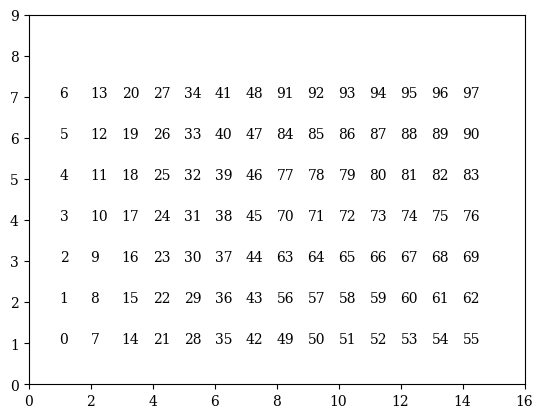

In [9]:
for i,c in data_coords_hgp.items():
    plt.text(c[0], c[1], str(i))
plt.xlim(0, 2*s+2)
plt.ylim(0, s+2)

Need ancilla qubits to be able to decide when and where they start the schedule. Maybe allow free move-anywhere-and-wait action that would be used to set the initialization spot? The wait would be allowed even in a blocked interval, but the end of the wait is an initialization that must be in an available interval.

Also need to let CX order be free



In [7]:
sched.total_duration()

44500

Issue at t=15100
	Overlapping: [99, 179] at pos (11.6, 0.8)
	Overlapping: [99, 179] at pos (11.6, 0.8)
Issue at t=15150
	Overlapping: [99, 179] at pos (11.6, 0.8)
	Overlapping: [99, 179] at pos (11.6, 0.8)
Issue at t=15200
	Overlapping: [99, 179] at pos (11.6, 0.8)
	Overlapping: [99, 179] at pos (11.6, 0.8)
Issue at t=15250
	Overlapping: [99, 179] at pos (11.6, 0.8)
	Overlapping: [99, 179] at pos (11.6, 0.8)
Issue at t=15300
	Overlapping: [99, 179] at pos (11.6, 0.8)
	Overlapping: [99, 179] at pos (11.6, 0.8)
Issue at t=15350
	Overlapping: [99, 179] at pos (11.6, 0.8)
	Overlapping: [99, 179] at pos (11.6, 0.8)
Issue at t=15400
	Overlapping: [99, 179] at pos (11.6, 0.8)
	Overlapping: [99, 179] at pos (11.6, 0.8)
Issue at t=15450
	Overlapping: [99, 179] at pos (11.6, 0.8)
	Overlapping: [99, 179] at pos (11.6, 0.8)
Issue at t=15500
	Overlapping: [99, 179] at pos (11.6, 0.8)
	Overlapping: [99, 179] at pos (11.6, 0.8)
Issue at t=15550
	Overlapping: [99, 179] at pos (11.6, 0.8)
	Overlapping:

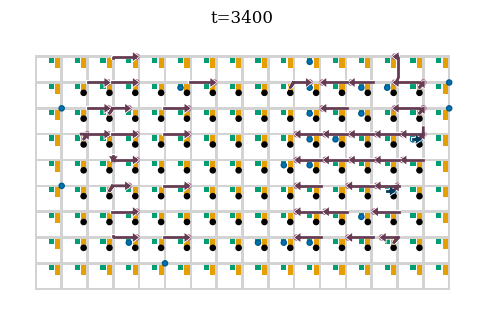

In [6]:
frames = sched.get_frames(50)
plotter.plot_transition(dev, code_hgp, frames[50:70])

Issue at t=15100
	Overlapping: [99, 179] at pos (11.6, 0.8)
	Overlapping: [99, 179] at pos (11.6, 0.8)
Issue at t=15150
	Overlapping: [99, 179] at pos (11.6, 0.8)
	Overlapping: [99, 179] at pos (11.6, 0.8)
Issue at t=15200
	Overlapping: [99, 179] at pos (11.6, 0.8)
	Overlapping: [99, 179] at pos (11.6, 0.8)
Issue at t=15250
	Overlapping: [99, 179] at pos (11.6, 0.8)
	Overlapping: [99, 179] at pos (11.6, 0.8)
Issue at t=15300
	Overlapping: [99, 179] at pos (11.6, 0.8)
	Overlapping: [99, 179] at pos (11.6, 0.8)
Issue at t=15350
	Overlapping: [99, 179] at pos (11.6, 0.8)
	Overlapping: [99, 179] at pos (11.6, 0.8)
Issue at t=15400
	Overlapping: [99, 179] at pos (11.6, 0.8)
	Overlapping: [99, 179] at pos (11.6, 0.8)
Issue at t=15450
	Overlapping: [99, 179] at pos (11.6, 0.8)
	Overlapping: [99, 179] at pos (11.6, 0.8)
Issue at t=15500
	Overlapping: [99, 179] at pos (11.6, 0.8)
	Overlapping: [99, 179] at pos (11.6, 0.8)
Issue at t=15550
	Overlapping: [99, 179] at pos (11.6, 0.8)
	Overlapping:

MovieWriter imagemagick unavailable; using Pillow instead.


KeyboardInterrupt: 

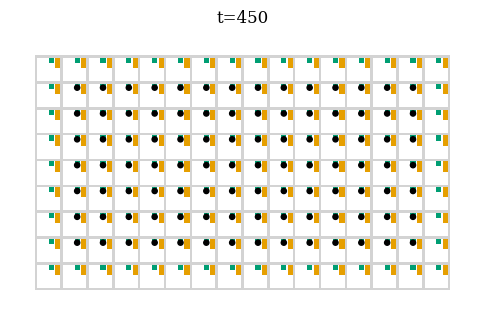

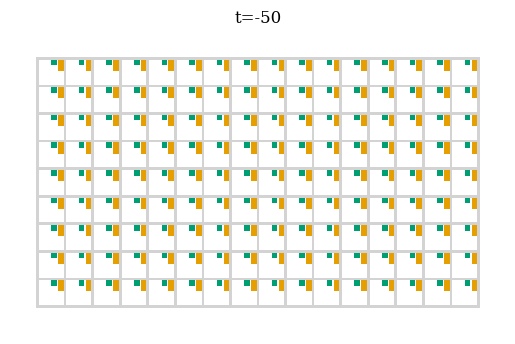

In [7]:
frames = sched.get_frames(50)
plotter.plot_device_snapshot(dev, code_hgp, frames[10])
anim = plotter.animate_device(dev, code_hgp, frames, 'anim_simplex.gif', fps=10)